**PREDICTION OF AQI FOR THE NEXT THREE DAYS**


IMPORTING LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import shap
%matplotlib inline


In [2]:
!pip install shap

In [3]:
pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 863.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21

DATA COLLECTION

In [4]:
df=pd.read_csv('karachi_aqi.csv')

In [5]:
df

,date,time,hour_of_day,day_of_week,is_weekend,aqi_index,pm2_5,pm10,co,no2,...,forecast_22_pressure,forecast_22_wind_speed,forecast_23_temp,forecast_23_humidity,forecast_23_pressure,forecast_23_wind_speed,forecast_24_temp,forecast_24_humidity,forecast_24_pressure,forecast_24_wind_speed
0,2025-08-03,01:51:02,1,6,1,58,18.50,63.77,74.79,0.08,...,1003,8.72,27.05,81,1002,9.18,27.26,81,1002,9.04
1,2025-08-03,03:49:47,3,6,1,58,19.45,70.52,73.85,0.08,...,1002,9.18,27.26,81,1002,9.04,27.69,76,1003,9.28
2,2025-08-03,04:47:38,4,6,1,59,19.86,76.58,73.34,0.07,...,1002,9.18,27.26,81,1002,9.04,27.69,76,1003,9.28
3,2025-08-03,05:25:34,5,6,1,59,19.86,76.58,73.34,0.07,...,1002,9.18,27.26,81,1002,9.04,27.69,76,1003,9.28
4,2025-08-03,06:27:03,6,6,1,58,19.87,81.87,73.08,0.05,...,1002,9.13,27.88,76,1003,9.31,28.55,73,1003,8.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,2025-07-24,19:17:05,19,3,0,63,21.08,82.11,80.58,0.09,...,997,7.30,28.31,78,998,7.37,28.18,78,998,6.51
272,2025-07-24,20:20:16,20,3,0,64,22.98,87.17,80.46,0.09,...,997,7.30,28.31,78,998,7.37,28.18,78,998,6.51
273,2025-07-24,21:18:57,21,3,0,64,26.79,102.96,79.63,0.09,...,998,7.37,28.18,78,998,6.51,27.92,81,997,7.41
274,2025-07-24,22:19:06,22,3,0,79,26.77,101.51,78.80,0.09,...,998,7.37,28.18,78,998,6.51,27.92,81,997,7.41


DATA PREPROCESSING


In [6]:
print('LENGTH OF DATASET:',len(df))

LENGTH OF DATASET: 276


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 113 entries, date to forecast_24_wind_speed
dtypes: float64(56), int64(55), object(2)
memory usage: 243.8+ KB


In [8]:
df.isnull().sum()

,0
date,0
time,0
hour_of_day,0
day_of_week,0
is_weekend,0
...,...
forecast_23_wind_speed,0
forecast_24_temp,0
forecast_24_humidity,0
forecast_24_pressure,0


<Axes: >

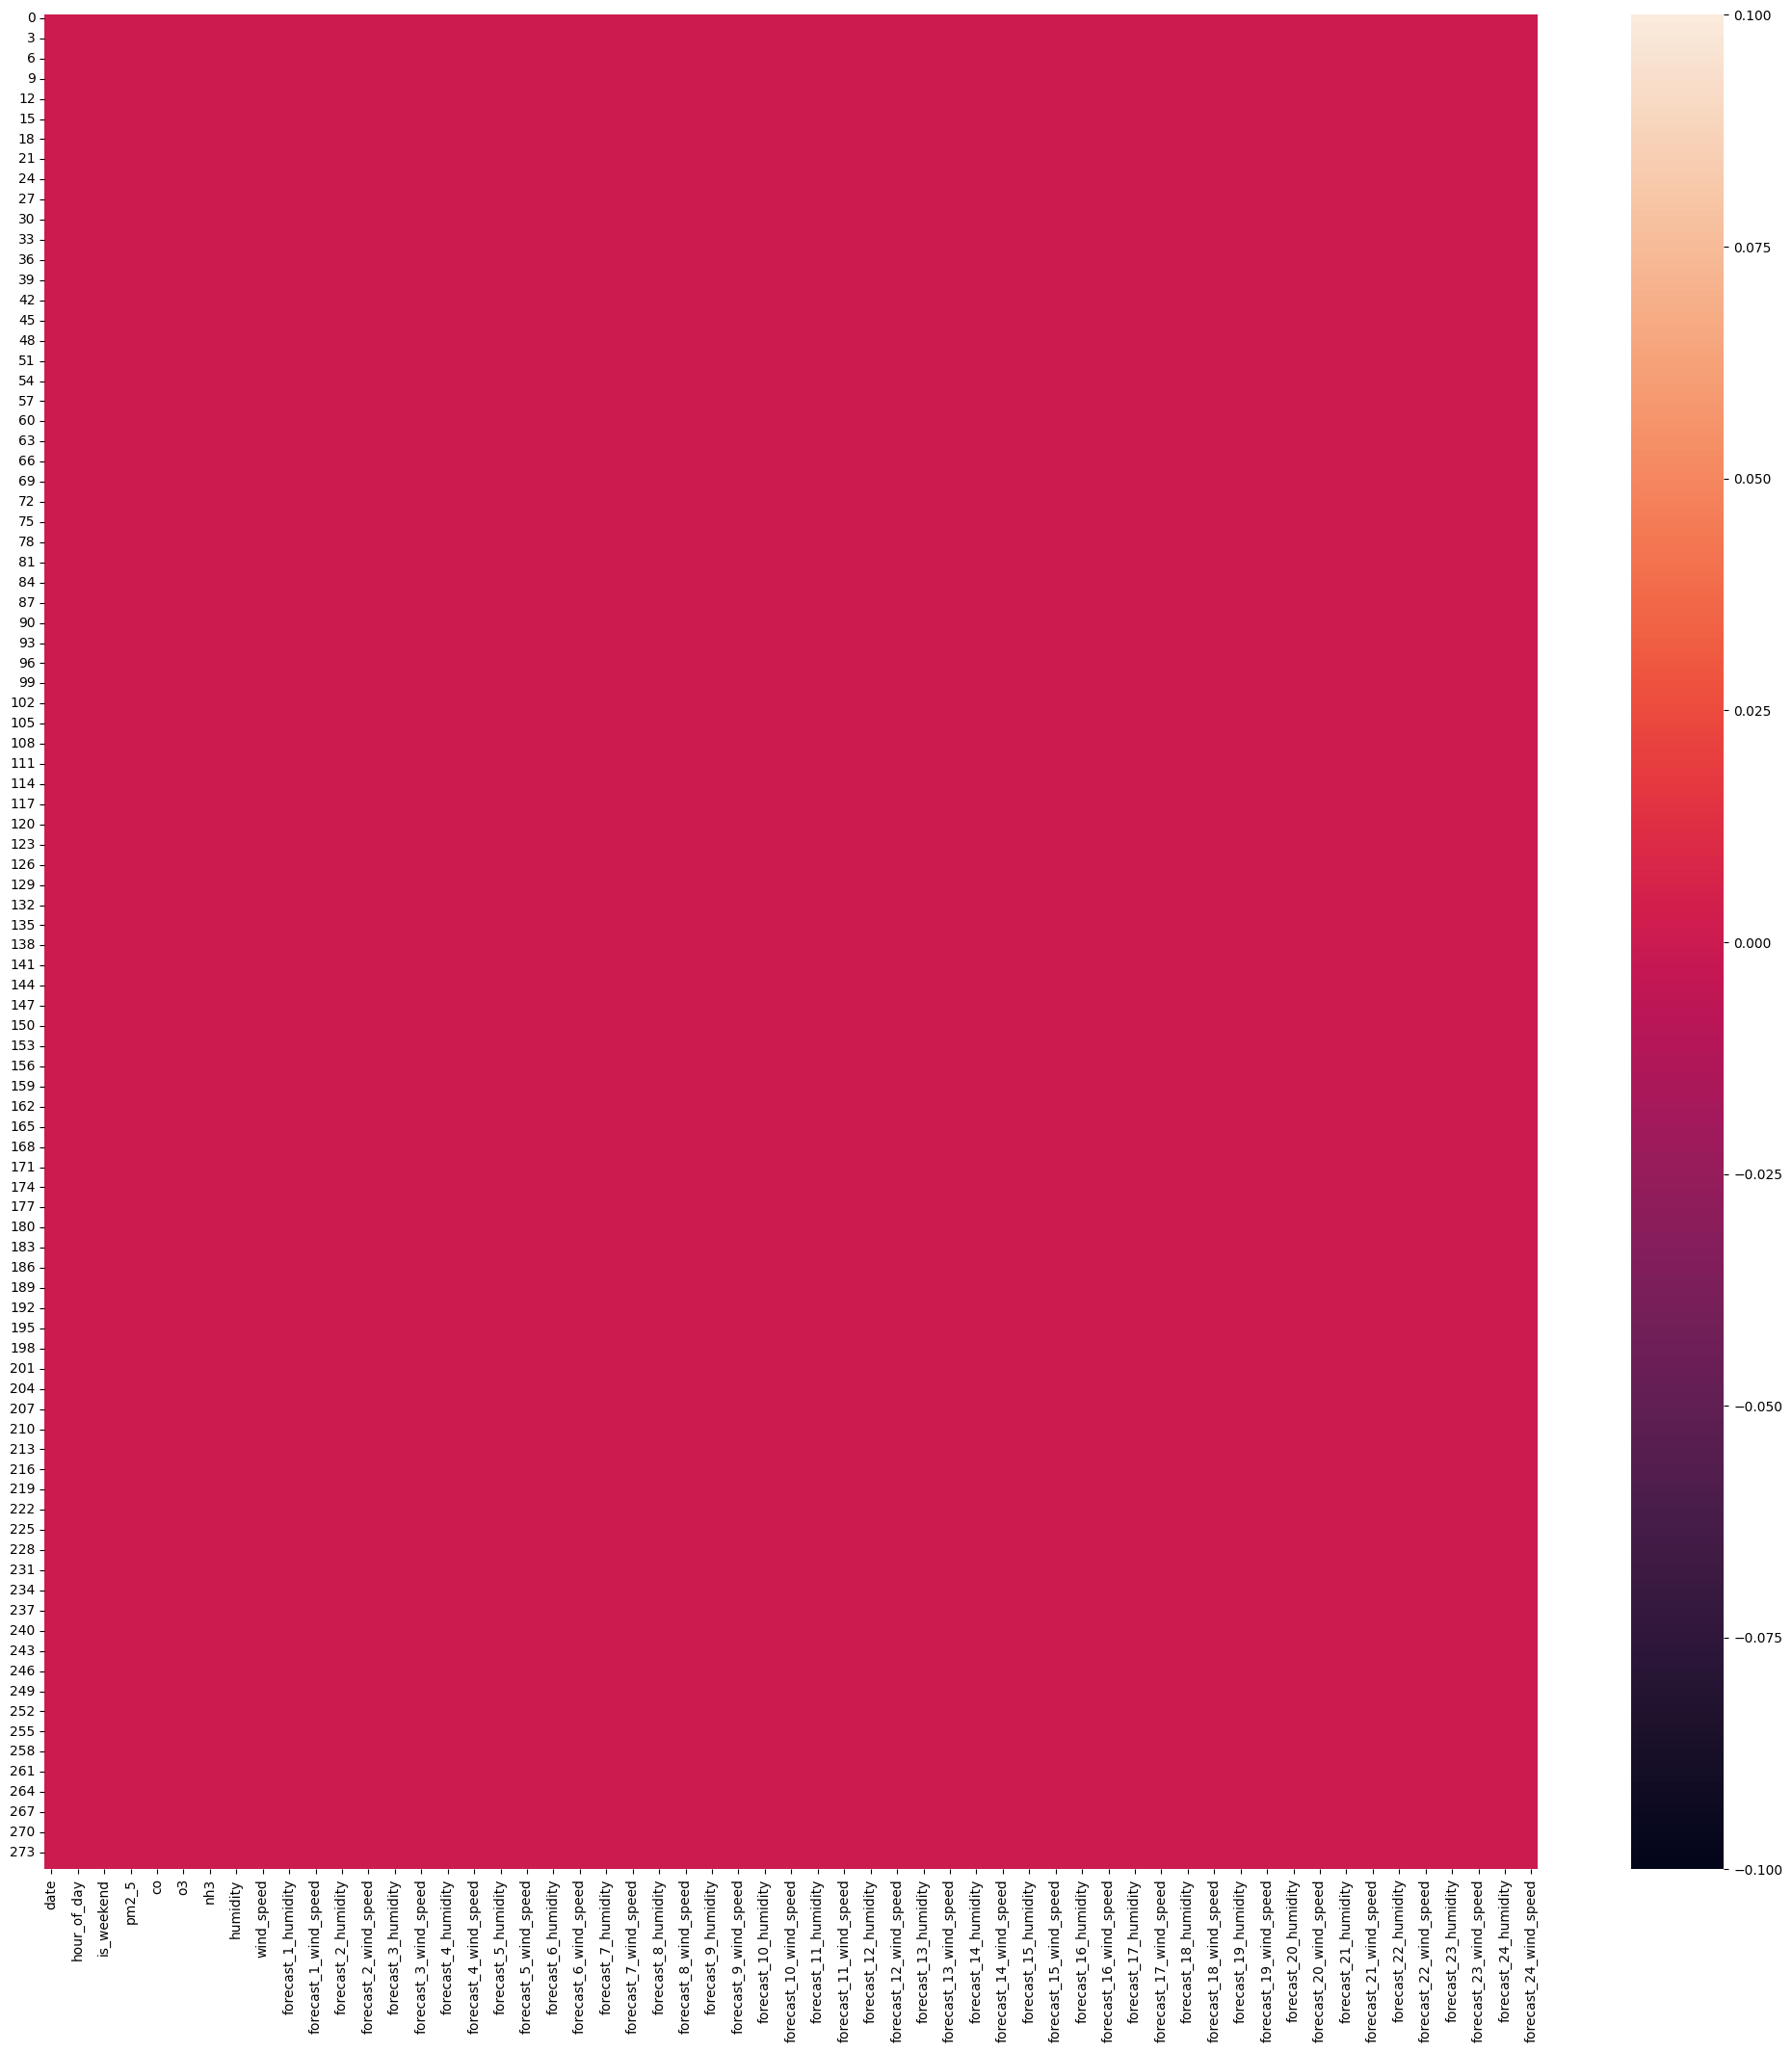

In [9]:
#PLOTTING NULL VALUES
plt.figure(figsize=(25,25))
sns.heatmap(df.isnull())

In [10]:
import pandas as pd

# Load the CSV
df = pd.read_csv("karachi_aqi.csv")

# Show all columns for verification
print("Original columns:")
print(df.columns.tolist())

# Drop columns that contain 'forecast' (case-insensitive)
columns_to_drop = [col for col in df.columns if 'forecast' in col.lower()]
df.drop(columns=columns_to_drop, inplace=True)

# Show columns after deletion
print("\nRemaining columns:")
print(df.columns.tolist())

# Save cleaned file
df.to_csv("cleaned_file.csv", index=False)

Original columns:
['date', 'time', 'hour_of_day', 'day_of_week', 'is_weekend', 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3', 'temp', 'humidity', 'pressure', 'wind_speed', 'forecast_1_temp', 'forecast_1_humidity', 'forecast_1_pressure', 'forecast_1_wind_speed', 'forecast_2_temp', 'forecast_2_humidity', 'forecast_2_pressure', 'forecast_2_wind_speed', 'forecast_3_temp', 'forecast_3_humidity', 'forecast_3_pressure', 'forecast_3_wind_speed', 'forecast_4_temp', 'forecast_4_humidity', 'forecast_4_pressure', 'forecast_4_wind_speed', 'forecast_5_temp', 'forecast_5_humidity', 'forecast_5_pressure', 'forecast_5_wind_speed', 'forecast_6_temp', 'forecast_6_humidity', 'forecast_6_pressure', 'forecast_6_wind_speed', 'forecast_7_temp', 'forecast_7_humidity', 'forecast_7_pressure', 'forecast_7_wind_speed', 'forecast_8_temp', 'forecast_8_humidity', 'forecast_8_pressure', 'forecast_8_wind_speed', 'forecast_9_temp', 'forecast_9_humidity', 'forecast_9_pressure', 'forecast_9_wind_speed', 'f

In [11]:
# Load the CSV
df1 = pd.read_csv("cleaned_file.csv")

In [12]:
# Columns to delete
columns_to_delete = ["date", "time", "hour_of_day", "day_of_week", "is_weekend"]

# Drop the columns
df1.drop(columns=columns_to_delete, inplace=True)

# Optional: Save to a new CSV
df1.to_csv("cleaned1_file.csv", index=False)

# Show remaining columns
print(df1.columns.tolist())


['aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3', 'temp', 'humidity', 'pressure', 'wind_speed']


In [13]:
df1

,aqi_index,pm2_5,pm10,co,no2,o3,so2,nh3,temp,humidity,pressure,wind_speed
0,58,18.50,63.77,74.79,0.08,47.00,0.28,0,27.9,74,1003,4.12
1,58,19.45,70.52,73.85,0.08,47.53,0.29,0,27.9,78,1003,5.14
2,59,19.86,76.58,73.34,0.07,47.64,0.31,0,28.9,74,1004,5.14
3,59,19.86,76.58,73.34,0.07,47.64,0.31,0,29.9,66,1004,6.17
4,58,19.87,81.87,73.08,0.05,47.72,0.32,0,29.9,66,1003,5.14
...,...,...,...,...,...,...,...,...,...,...,...,...
271,63,21.08,82.11,80.58,0.09,46.82,0.37,0,28.9,70,997,4.12
272,64,22.98,87.17,80.46,0.09,46.45,0.37,0,28.9,70,997,4.12
273,64,26.79,102.96,79.63,0.09,45.39,0.41,0,28.9,70,997,5.14
274,79,26.77,101.51,78.80,0.09,45.07,0.40,0,28.9,70,996,3.09


EXPLORATORY DATA ANALYSIS


In [14]:
#Summary Statistics

In [15]:
df.describe()
df["aqi_index"].value_counts().sort_index()

,count
aqi_index,
54,1
55,1
56,3
57,1
58,9
59,3
60,8
61,15
62,12


In [16]:
 #Time-Based Trends

COLUMNS: ['date', 'time', 'hour_of_day', 'day_of_week', 'is_weekend', 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3', 'temp', 'humidity', 'pressure', 'wind_speed']


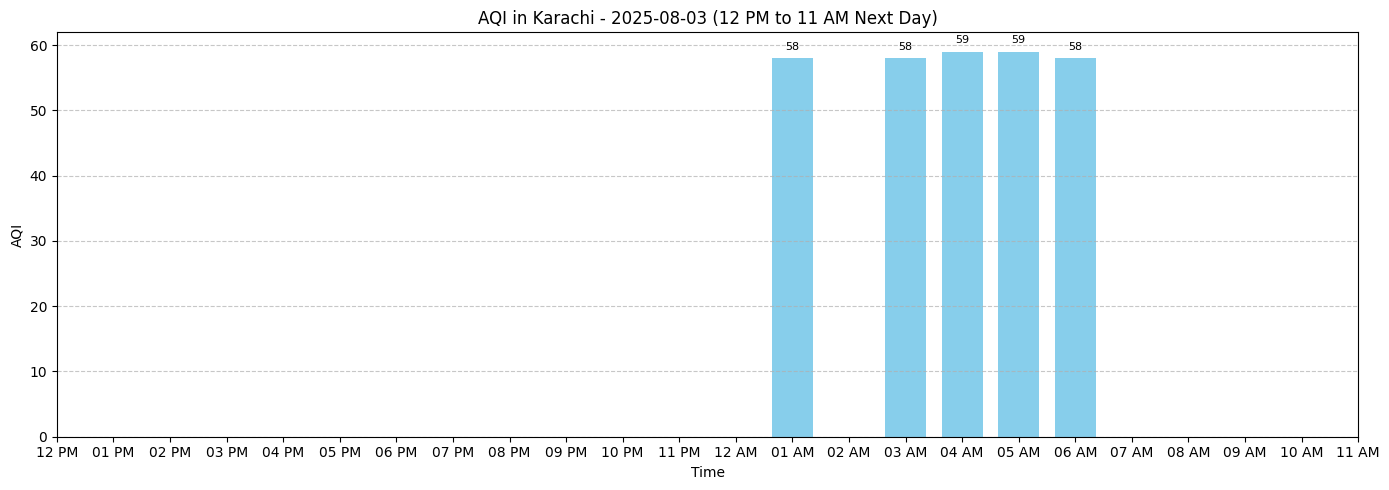

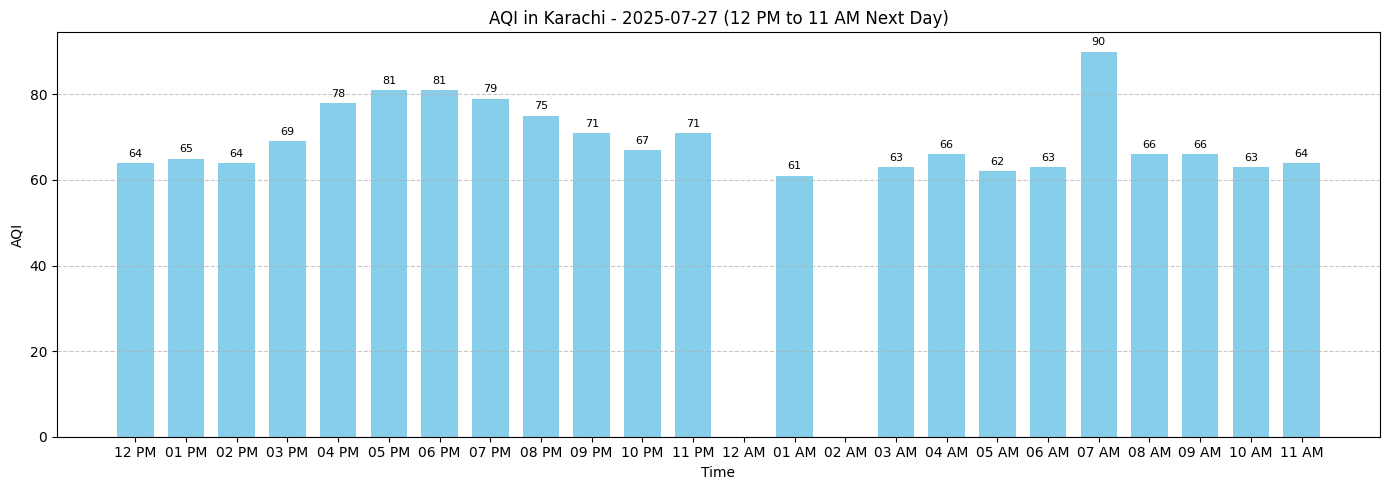

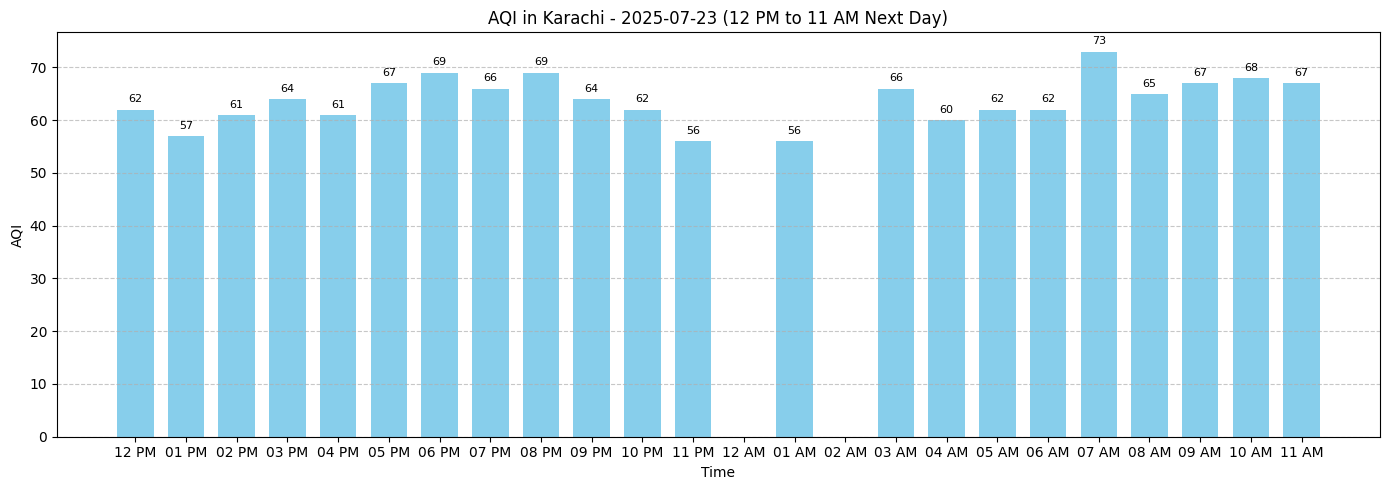

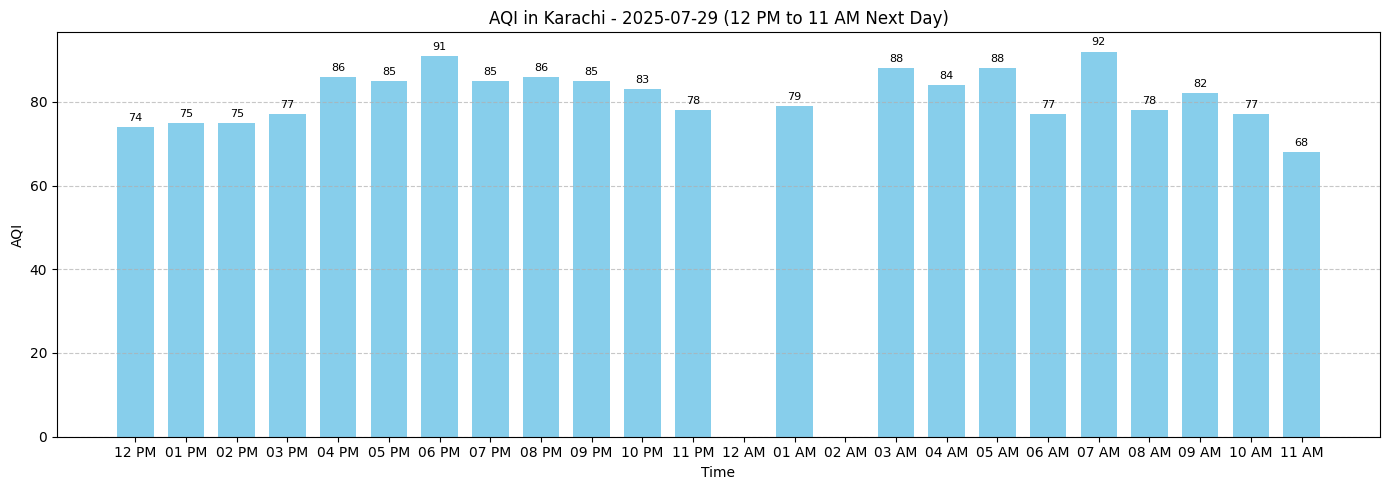

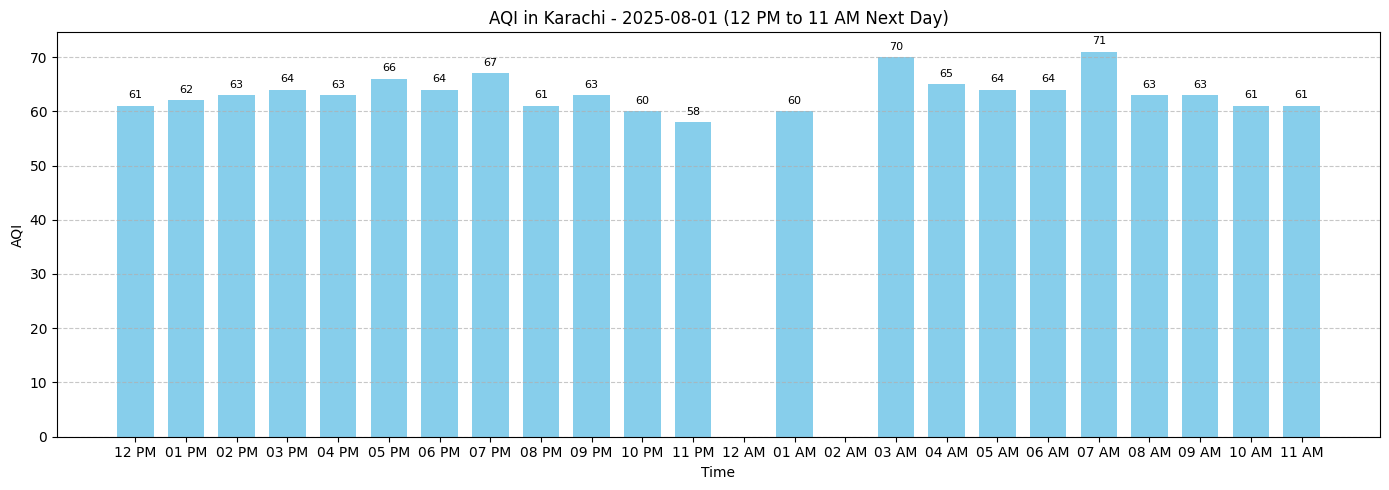

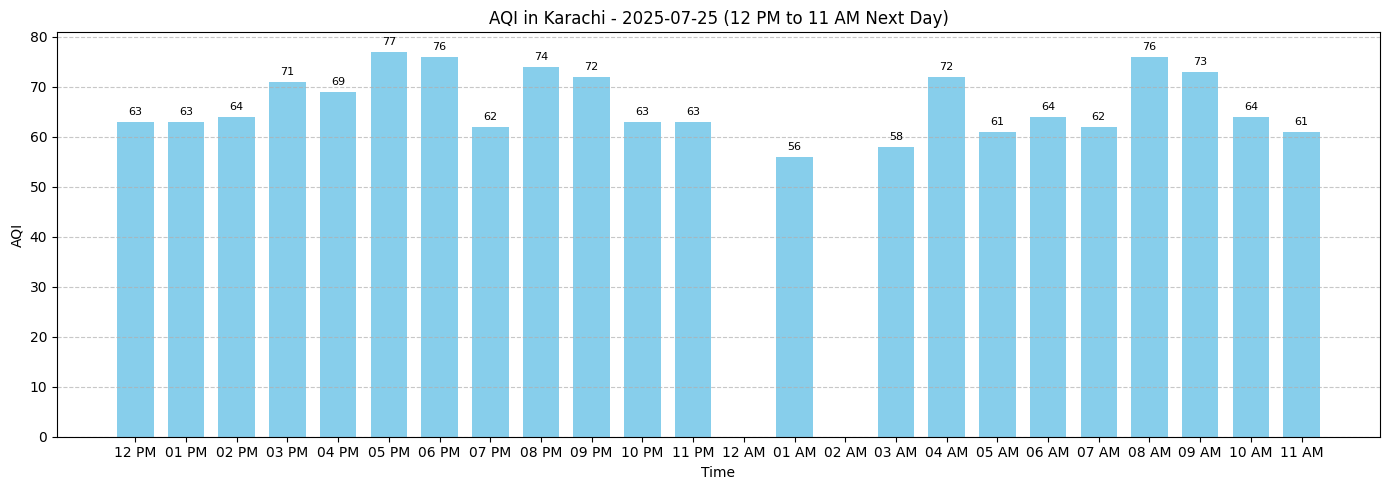

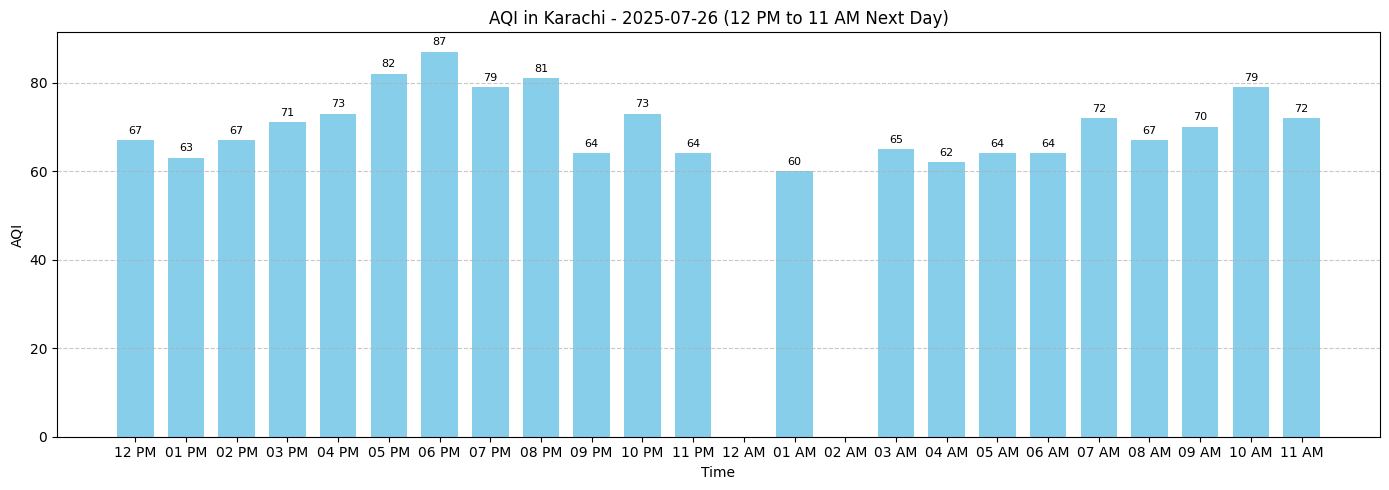

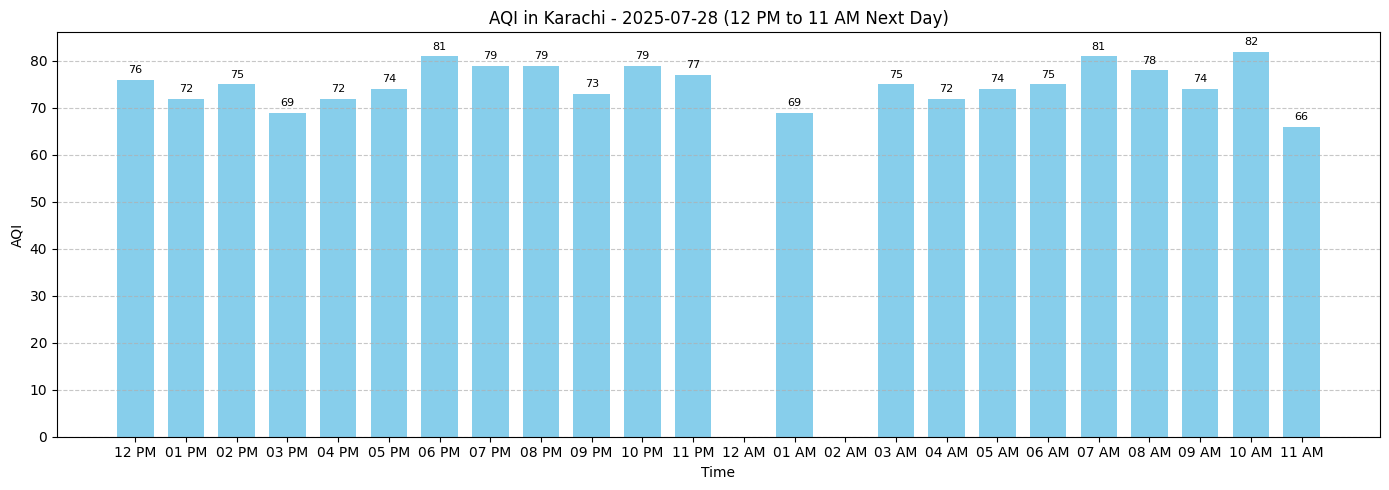

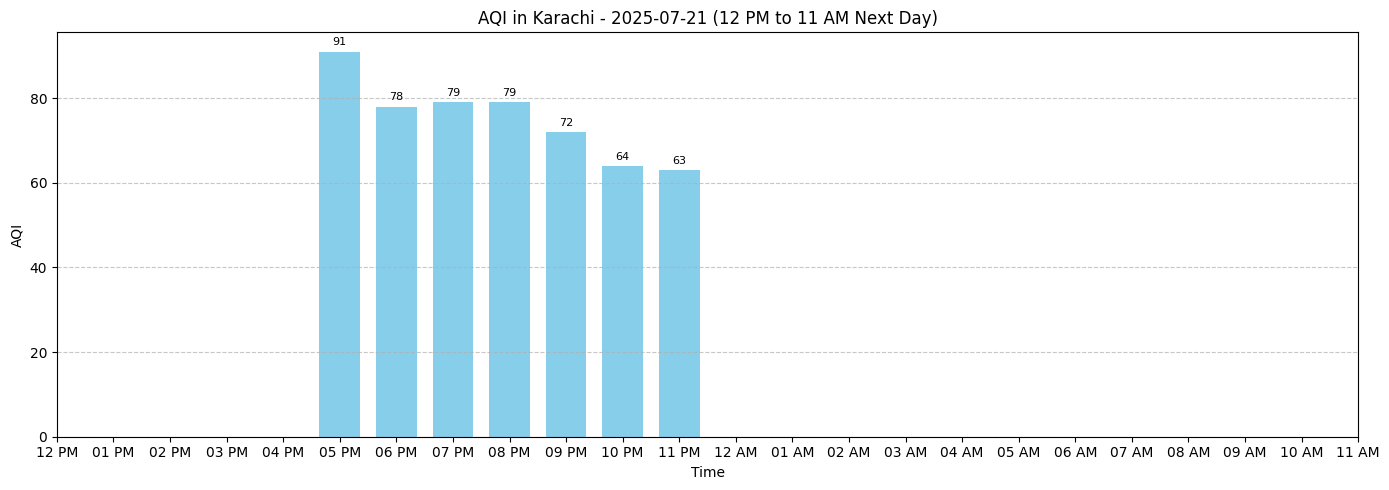

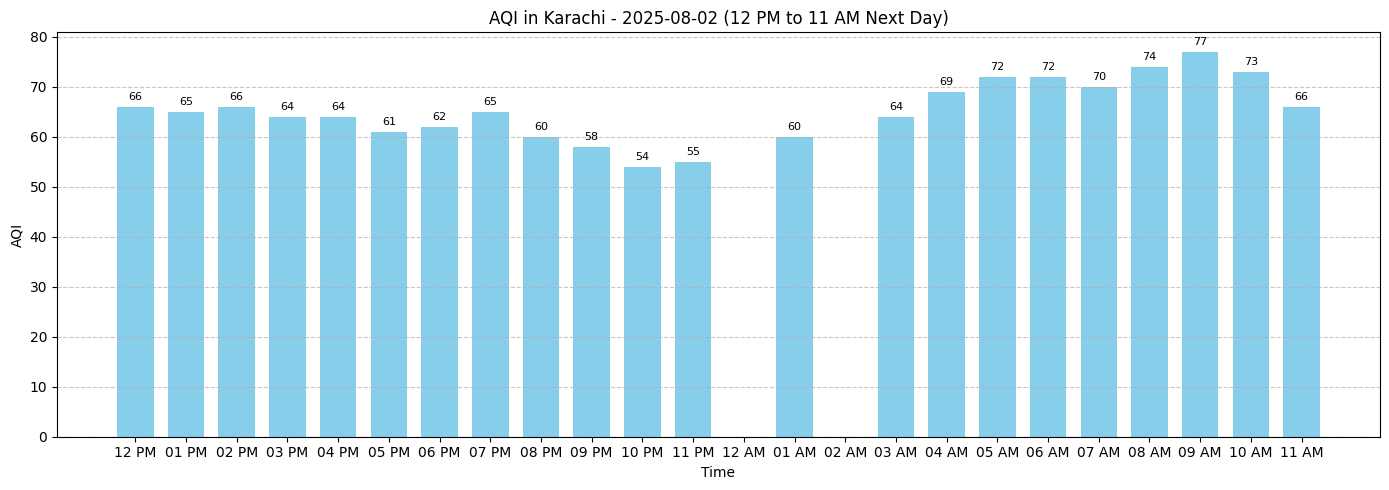

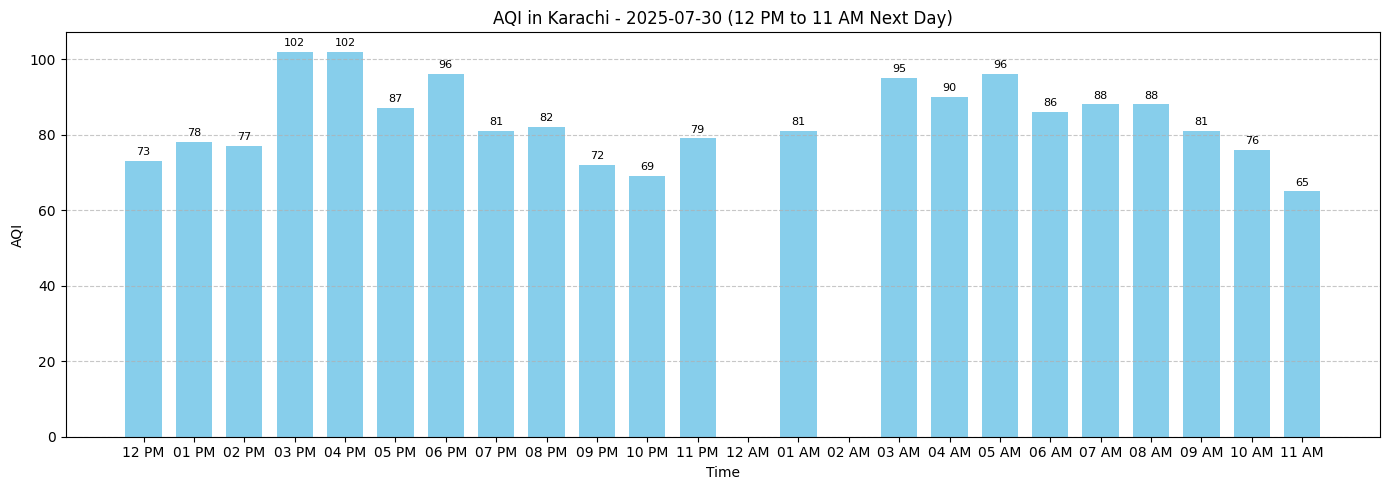

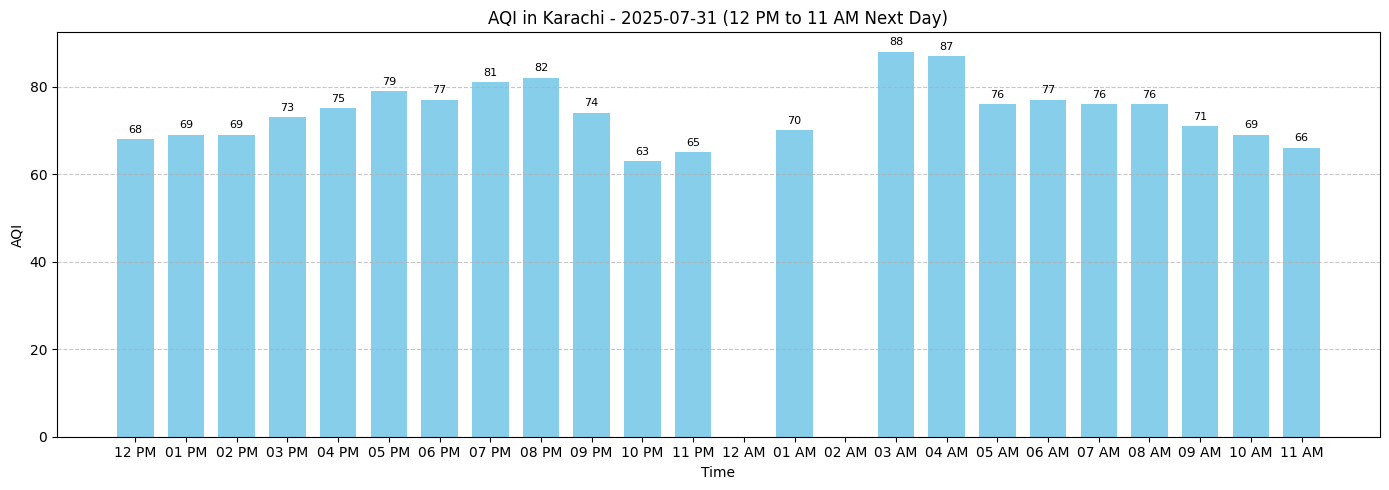

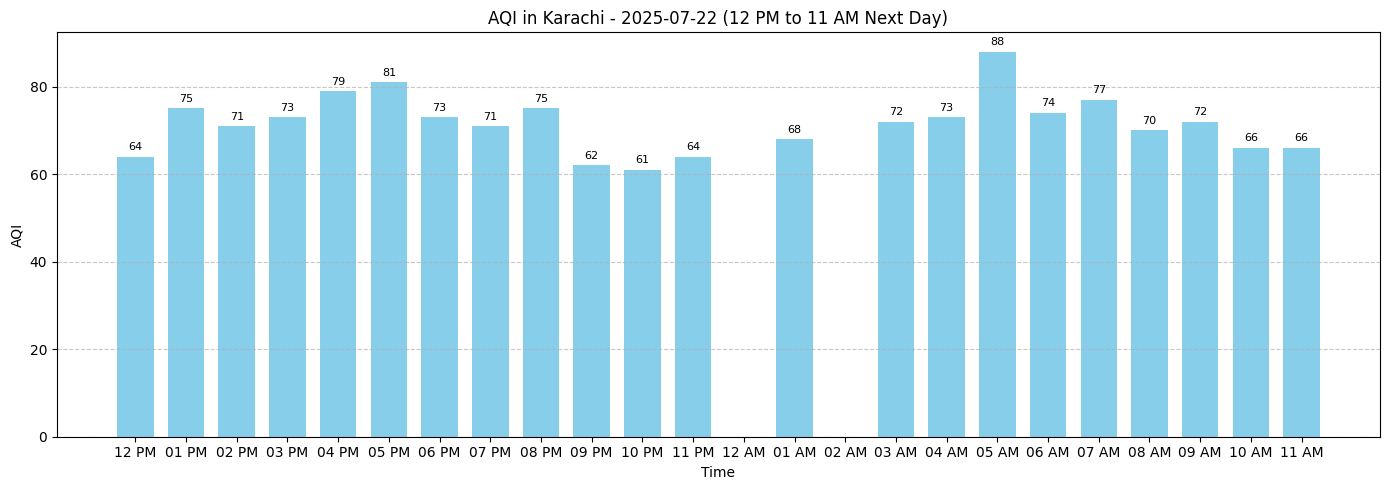

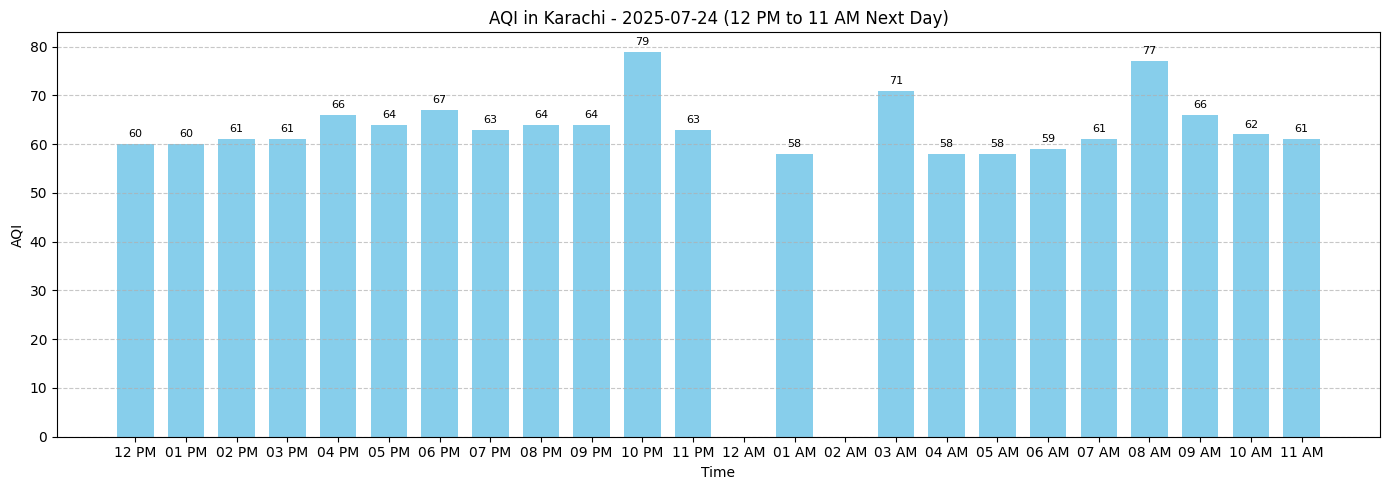

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# STEP 1: Strip all column names of spaces
df.columns = df.columns.str.strip()

# STEP 2: Print column names to debug
print("COLUMNS:", df.columns.tolist())

# STEP 3: Parse 'date' and 'time' to create datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['datetime'] = pd.to_datetime(df['date'].dt.strftime('%Y-%m-%d') + ' ' + df['time'], errors='coerce')

# STEP 4: Drop rows with invalid datetime
df = df.dropna(subset=['datetime'])

# STEP 5: Extract hour
df['hour'] = df['datetime'].dt.hour

# STEP 6: Get unique dates
unique_dates = df['datetime'].dt.date.unique()

# STEP 7: Define desired hour sequence (now includes 12 PM too)
desired_hours = list(range(12, 24)) + list(range(0, 12))  # 12 PM to 11 PM, then 12 AM to 11 AM

# STEP 8: Plot for each day
for day in unique_dates:
    day_df = df[df['datetime'].dt.date == day]

    # Get average AQI per hour
    hourly_avg = day_df.groupby(day_df['datetime'].dt.hour)['aqi_index'].mean()
    hourly_avg = hourly_avg.reindex(desired_hours)  # Ensure all desired hours are included

    # Create labels for each hour (same day or next day)
    hour_labels = []
    for hr in desired_hours:
        if hr >= 12:
            dt = pd.Timestamp(f"{day} {hr:02d}:00")
        else:
            dt = pd.Timestamp(f"{pd.Timestamp(day) + pd.Timedelta(days=1):%Y-%m-%d} {hr:02d}:00")
        hour_labels.append(dt)

    display_labels = [dt.strftime('%I %p') for dt in hour_labels]

    # Plot
    plt.figure(figsize=(14, 5))
    bars = plt.bar(hour_labels, hourly_avg, color='skyblue', width=0.03)

    # Add AQI values on top of bars
    for bar, val in zip(bars, hourly_avg):
        if not pd.isna(val):
            plt.text(bar.get_x() + bar.get_width()/2, val + 1, f'{int(round(val))}',
                     ha='center', va='bottom', fontsize=8)

    plt.xticks(hour_labels, display_labels, rotation=0)
    plt.title(f"AQI in Karachi - {day} (12 PM to 11 AM Next Day)")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [18]:
#Correlation Heatmap


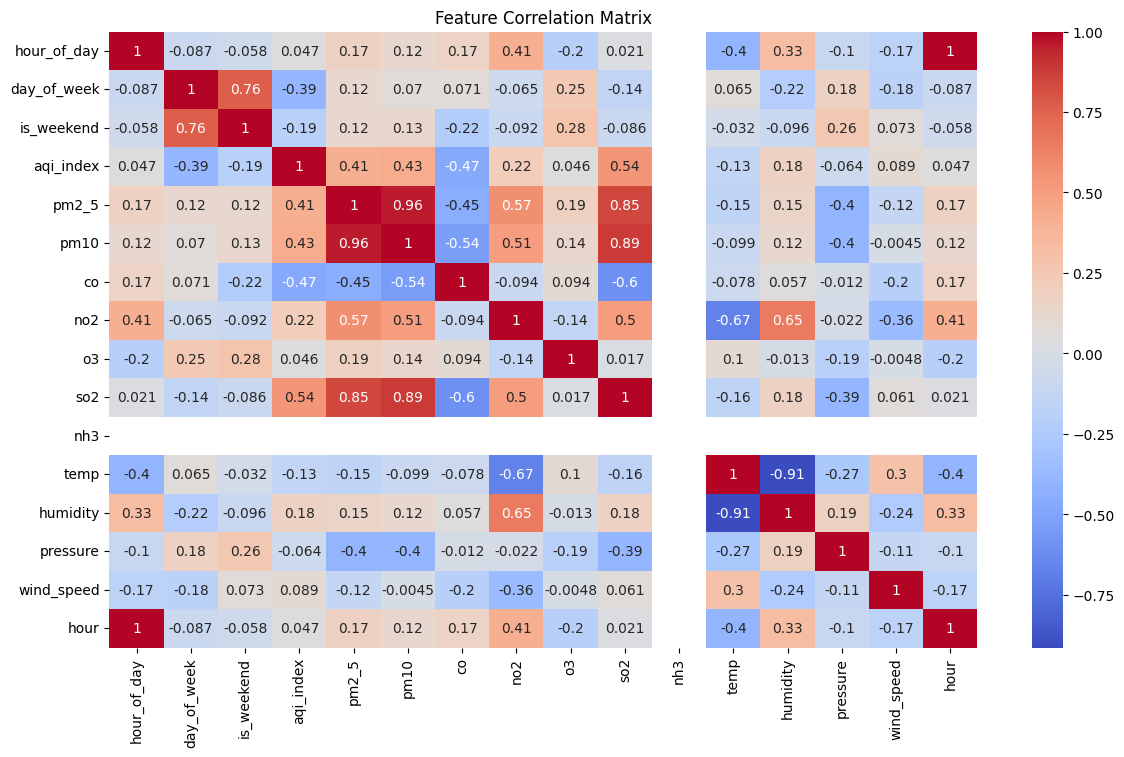

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric columns (e.g., strings like 'time')
numeric_df = df.select_dtypes(include=["number"])

# Correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


In [20]:
# Daily Patterns

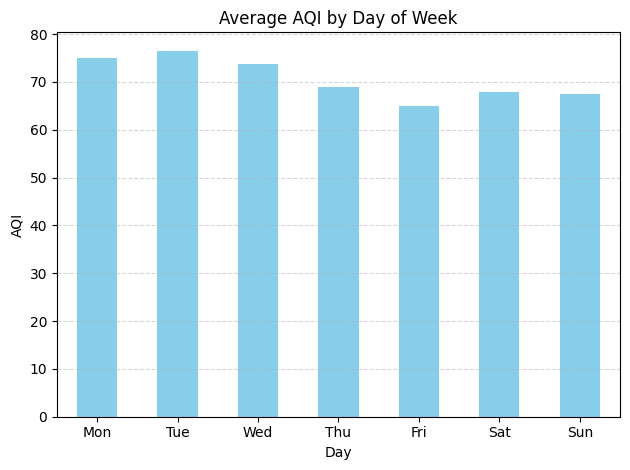

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Map weekday numbers to names
weekday_map = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

# Ensure 'day_of_week' column exists
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['datetime'].dt.dayofweek  # 0 = Monday

# Group and rename index with weekday names
avg_aqi_by_day = df.groupby("day_of_week")["aqi_index"].mean()
avg_aqi_by_day.index = avg_aqi_by_day.index.map(weekday_map)

# Plot
ax = avg_aqi_by_day.plot(kind="bar", title="Average AQI by Day of Week", color="skyblue")
ax.set_ylabel("AQI")
ax.set_xlabel("Day")
plt.xticks(rotation=0)  # Keep weekday labels straight
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [22]:
#Hourly Patterns

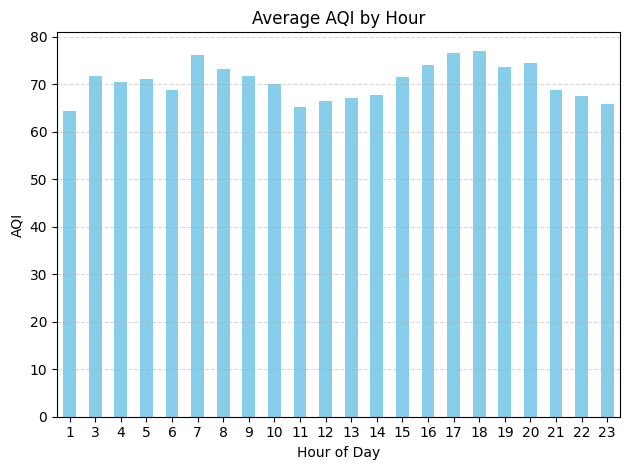

In [23]:
import matplotlib.pyplot as plt

# Plot average AQI by hour with light blue bars
ax = df.groupby("hour_of_day")["aqi_index"].mean().plot(
    kind="bar",
    title="Average AQI by Hour",
    color='skyblue'  # light blue color
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("AQI")

plt.xticks(rotation=0)  # Keep hour labels straight (horizontal)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


FEATURE ENGINEERING

1.FOR TIME BASED FEATURES


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import sys

# === CONFIGURATION ===
CSV_PATH = "karachi_aqi.csv"

# === Load data ===
if not os.path.exists(CSV_PATH):
    print(f"❌ File not found: {CSV_PATH}")
    sys.exit(1)

df = pd.read_csv(CSV_PATH)

# === Check required columns ===
required_cols = ["pm2_5", "date", "time"]
for col in required_cols:
    if col not in df.columns:
        print(f"❌ Missing required column: {col}")
        sys.exit(1)

df = df.dropna(subset=["pm2_5"])

# === Compute AQI from PM2.5 if not already present ===
def calculate_aqi_from_pm25(pm2_5):
    if pd.isna(pm2_5):
        return None
    if pm2_5 <= 12:
        return (50 / 12) * pm2_5
    elif pm2_5 <= 35.4:
        return ((100 - 51) / (35.4 - 12.1)) * (pm2_5 - 12.1) + 51
    elif pm2_5 <= 55.4:
        return ((150 - 101) / (55.4 - 35.5)) * (pm2_5 - 35.5) + 101
    else:
        return 200

if "AQI" not in df.columns:
    df["AQI"] = df["pm2_5"].apply(calculate_aqi_from_pm25)

df = df.dropna(subset=["aqi_index"])

# === Create timestamp ===
df["timestamp"] = pd.to_datetime(df["date"] + " " + df["time"])
df = df.sort_values("timestamp")

# === Feature selection ===
selected_features = [
    "pm2_5", "pm10", "co", "no2", "o3", "so2", "nh3",
    "temp", "humidity", "pressure", "wind_speed",
    "hour_of_day", "day_of_week", "is_weekend"
]
for i in range(1, 7):
    selected_features += [
        f"forecast_{i}_temp",
        f"forecast_{i}_humidity",
        f"forecast_{i}_pressure",
        f"forecast_{i}_wind_speed"
    ]

missing = [f for f in selected_features if f not in df.columns]
if missing:
    print(f"❌ Missing feature columns: {missing}")
    sys.exit(1)


In [25]:
# Show columns after deletion
print("\nRemaining columns:")
print(df.columns.tolist())



Remaining columns:
['date', 'time', 'hour_of_day', 'day_of_week', 'is_weekend', 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3', 'temp', 'humidity', 'pressure', 'wind_speed', 'forecast_1_temp', 'forecast_1_humidity', 'forecast_1_pressure', 'forecast_1_wind_speed', 'forecast_2_temp', 'forecast_2_humidity', 'forecast_2_pressure', 'forecast_2_wind_speed', 'forecast_3_temp', 'forecast_3_humidity', 'forecast_3_pressure', 'forecast_3_wind_speed', 'forecast_4_temp', 'forecast_4_humidity', 'forecast_4_pressure', 'forecast_4_wind_speed', 'forecast_5_temp', 'forecast_5_humidity', 'forecast_5_pressure', 'forecast_5_wind_speed', 'forecast_6_temp', 'forecast_6_humidity', 'forecast_6_pressure', 'forecast_6_wind_speed', 'forecast_7_temp', 'forecast_7_humidity', 'forecast_7_pressure', 'forecast_7_wind_speed', 'forecast_8_temp', 'forecast_8_humidity', 'forecast_8_pressure', 'forecast_8_wind_speed', 'forecast_9_temp', 'forecast_9_humidity', 'forecast_9_pressure', 'forecast_9_wind_speed', 

2.WITHOUT TIME BASED FEATURES

In [26]:
# === CONFIGURATION ===
CSV_PATH = "cleaned1_file.csv"

# === Load data ===
if not os.path.exists(CSV_PATH):
    print(f"❌ File not found: {CSV_PATH}")
    sys.exit(1)

df1 = pd.read_csv(CSV_PATH)

# === Check required columns ===
required_cols = [
    'aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'o3',
    'so2', 'nh3', 'temp', 'humidity', 'pressure', 'wind_speed'
]

missing = [col for col in required_cols if col not in df.columns]
if missing:
    print(f"❌ Missing required columns: {missing}")
    sys.exit(1)

df1 = df1.dropna(subset=["pm2_5", "aqi_index"])

# === Feature selection (NO timestamp or time-related features) ===
selected_features = [
    'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3',
    'temp', 'humidity', 'pressure', 'wind_speed'
]

target_col = "aqi_index"

# === Final check for features ===
missing_feats = [f for f in selected_features if f not in df.columns]
if missing_feats:
    print(f"❌ Missing feature columns: {missing_feats}")
    sys.exit(1)

In [27]:
# Show columns after deletion
print("\nRemaining columns:")
print(df.columns.tolist())



Remaining columns:
['date', 'time', 'hour_of_day', 'day_of_week', 'is_weekend', 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'o3', 'so2', 'nh3', 'temp', 'humidity', 'pressure', 'wind_speed', 'forecast_1_temp', 'forecast_1_humidity', 'forecast_1_pressure', 'forecast_1_wind_speed', 'forecast_2_temp', 'forecast_2_humidity', 'forecast_2_pressure', 'forecast_2_wind_speed', 'forecast_3_temp', 'forecast_3_humidity', 'forecast_3_pressure', 'forecast_3_wind_speed', 'forecast_4_temp', 'forecast_4_humidity', 'forecast_4_pressure', 'forecast_4_wind_speed', 'forecast_5_temp', 'forecast_5_humidity', 'forecast_5_pressure', 'forecast_5_wind_speed', 'forecast_6_temp', 'forecast_6_humidity', 'forecast_6_pressure', 'forecast_6_wind_speed', 'forecast_7_temp', 'forecast_7_humidity', 'forecast_7_pressure', 'forecast_7_wind_speed', 'forecast_8_temp', 'forecast_8_humidity', 'forecast_8_pressure', 'forecast_8_wind_speed', 'forecast_9_temp', 'forecast_9_humidity', 'forecast_9_pressure', 'forecast_9_wind_speed', 

TRAINING THE MODEL

WITH TIME BASED FEATURES

In [28]:
X = df[selected_features].copy()
y = df["AQI"]

MODELS


1.RIDGE REGRESSION - WITH TIME BASED FEATURES

In [29]:
from sklearn.linear_model import Ridge

# Drop constant columns (if any)
X = X.loc[:, X.nunique() > 1]

# === TimeSeries Split ===
tscv = TimeSeriesSplit(n_splits=5)
mae_list, rmse_list, r2_list = [], [], []

# === Initialize Ridge Model ===
ridge_model = Ridge(alpha=1.0)

print("Training Ridge Regression Model...")

# === Cross-Validation Training ===
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)

    mae_list.append(mean_absolute_error(y_test, y_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_list.append(r2_score(y_test, y_pred))

# === Final Model Training on Full Data ===
ridge_model.fit(X, y)
joblib.dump(ridge_model, "model_ridge.pkl")

# === Predict full data for visualization ===
y_pred_all = ridge_model.predict(X)



# === Evaluation Results ===
print("\n✅ Ridge Regression Evaluation Metrics:")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")


Training Ridge Regression Model...

✅ Ridge Regression Evaluation Metrics:
   MAE       : 0.54
   RMSE      : 0.75
   R² Score  : 0.99


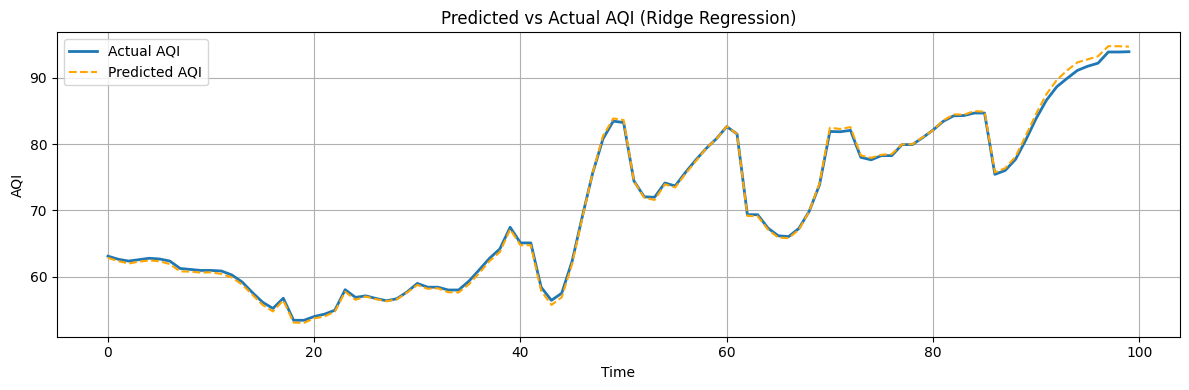

In [30]:
# === Plot first 100 predictions ===
plt.figure(figsize=(12, 4))
plt.plot(y.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all[:100], label="Predicted AQI", linestyle="--", color="orange")
plt.title("Predicted vs Actual AQI (Ridge Regression)")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_accuracy_ridge.png")


SHAP explanations


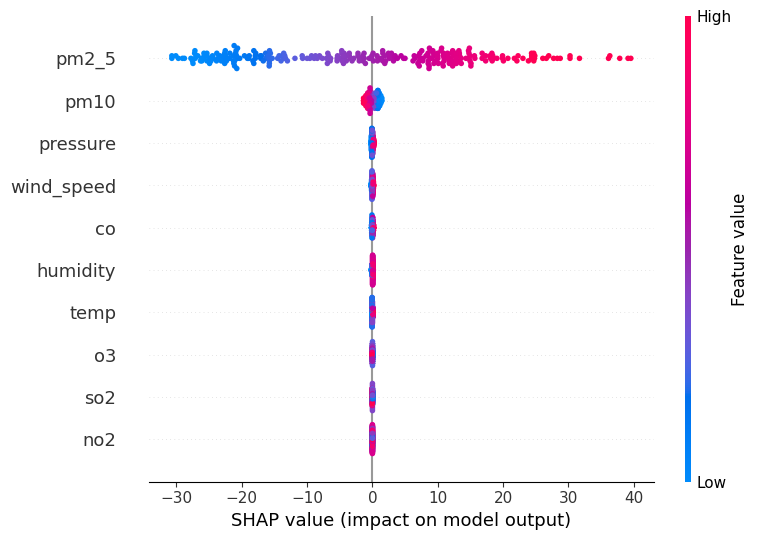

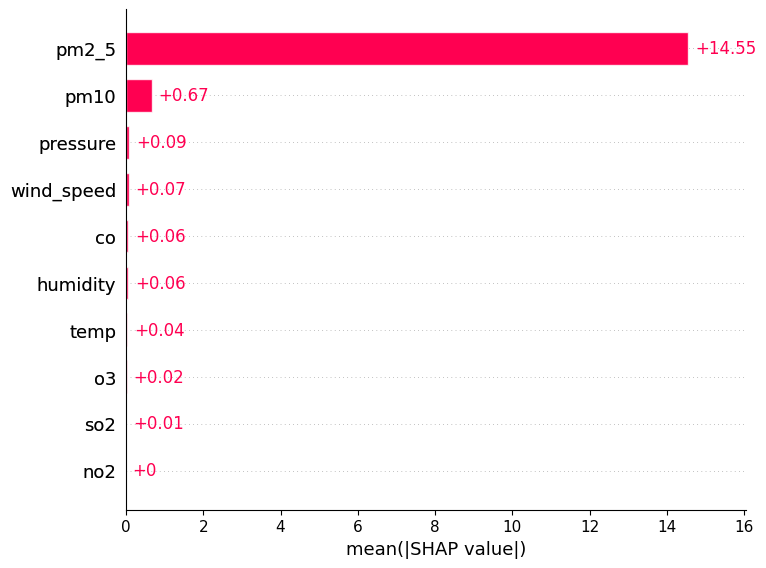

In [31]:
# === SHAP EXPLAINABILITY ===
print( "SHAP explanations")
explainer = shap.Explainer(ridge_model,X)
shap_values = explainer(X)

# === SHAP Summary Plot ===
shap.summary_plot(shap_values, X)
# === SHAP Bar Plot ===
shap.plots.bar(shap_values)

2. XGBoost model - WITH TIME BASED FEATURES

In [32]:
# === XGBoost Model ===
model1 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

print("Training XGBoost")

for train_idx, test_idx in tscv.split(X):
    X3_train, X3_test = X.iloc[train_idx], X.iloc[test_idx]
    y3_train, y3_test = y.iloc[train_idx], y.iloc[test_idx]

    model1.fit(X3_train, y3_train)
    y3_pred = model1.predict(X3_test)

    mae_list.append(mean_absolute_error(y3_test, y3_pred))
    rmse_list.append(np.sqrt(mean_squared_error(y3_test, y3_pred)))
    r2_list.append(r2_score(y3_test, y3_pred))

# === Final training ===
model1.fit(X, y)
joblib.dump(model1, "model_xgboost1.pkl")


# === Predict full set ===
y_pred_all3 = model1.predict(X)


# === Evaluation Metrics ===
print("\nEvaluation Metrics (Average from XGBoost):")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")


Training XGBoost

Evaluation Metrics (Average from XGBoost):
   MAE       : 2.62
   RMSE      : 3.27
   R² Score  : 0.22


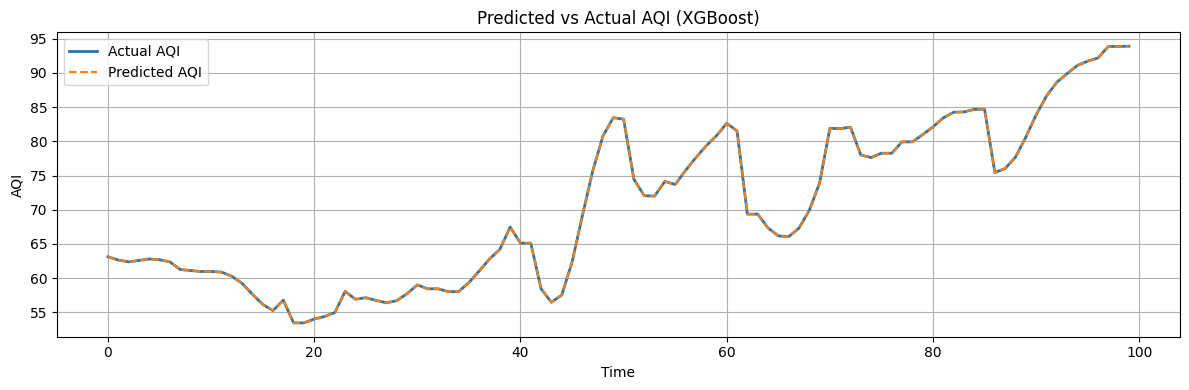

In [33]:
# === Plot first 100 predictions ===
plt.figure(figsize=(12, 4))
plt.plot(y.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all3[:100], label="Predicted AQI", linestyle="--")
plt.title("Predicted vs Actual AQI (XGBoost)")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("plot_accuracy_lightgbm.png")

SHAP explanations
Saved SHAP summary plot to shap_summary_xgboost.png
 Saved SHAP bar plot to shap_bar_xgboost.png


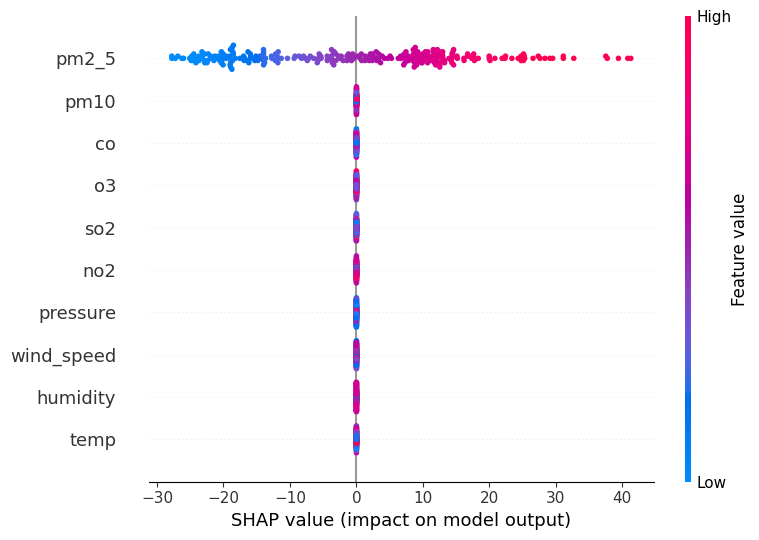

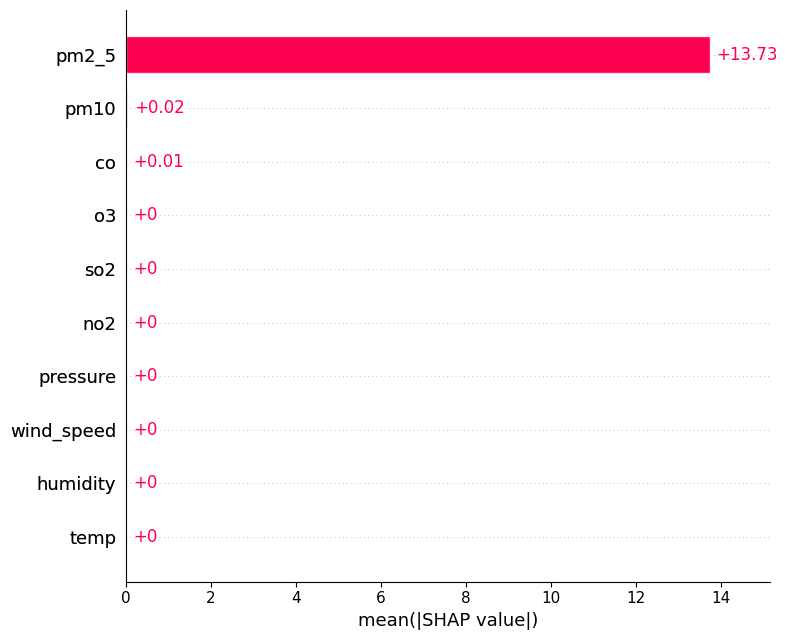

In [34]:
# === SHAP Explainability ===
print("SHAP explanations")
explainer = shap.Explainer(model1)
shap_values = explainer(X)

# === SHAP summary plot ===
plt.figure()
shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()
plt.savefig("shap_summary_xgboost.png")
print("Saved SHAP summary plot to shap_summary_xgboost.png")

# === SHAP bar plot ===
plt.figure()
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.savefig("shap_bar_xgboost.png")
print(" Saved SHAP bar plot to shap_bar_xgboost.png")

3. LINEAR REGRESSION MODEL - WITH TIME BASED FEATURES

In [35]:
# === Initialize Linear Regression Model ===
model2 = LinearRegression()
print("Linear Regression...")

# === TimeSeries Cross-validation Training ===
for train_idx, test_idx in tscv.split(X):
    X4_train, X4_test = X.iloc[train_idx], X.iloc[test_idx]
    y4_train, y4_test = y.iloc[train_idx], y.iloc[test_idx]

    model2.fit(X4_train, y4_train)
    y_pred4 = model2.predict(X4_test)

    mae_list.append(mean_absolute_error(y4_test, y_pred4))
    rmse_list.append(np.sqrt(mean_squared_error(y4_test, y_pred4)))
    r2_list.append(r2_score(y4_test, y_pred4))

# === Final Training on All Data ===
model2.fit(X, y)
joblib.dump(model2, "model_linear1.pkl")
print("✅ Model saved to model_linear.pkl")

# === Predict on Full Dataset ===
y_pred_all4 = model2.predict(X)

# === Print Metrics ===
print("\n📈 Evaluation Metrics (Average from TimeSeriesSplit):")
print(f"   MAE       : {np.mean(mae_list):.2f}")
print(f"   RMSE      : {np.mean(rmse_list):.2f}")
print(f"   R² Score  : {np.mean(r2_list):.2f}")

Linear Regression...
✅ Model saved to model_linear.pkl

📈 Evaluation Metrics (Average from TimeSeriesSplit):
   MAE       : 1.87
   RMSE      : 2.38
   R² Score  : 0.48


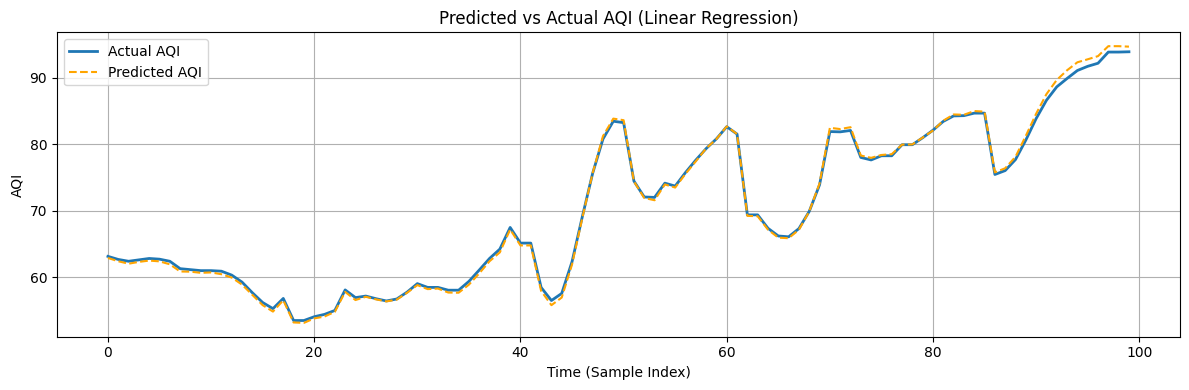

In [36]:
# === Plot Actual vs Predicted ===
plt.figure(figsize=(12, 4))
plt.plot(y.values[:100], label="Actual AQI", linewidth=2)
plt.plot(y_pred_all4[:100], label="Predicted AQI", linestyle="--", color="orange")
plt.title("Predicted vs Actual AQI (Linear Regression)")
plt.xlabel("Time (Sample Index)")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

🔍 Generating SHAP explanations...


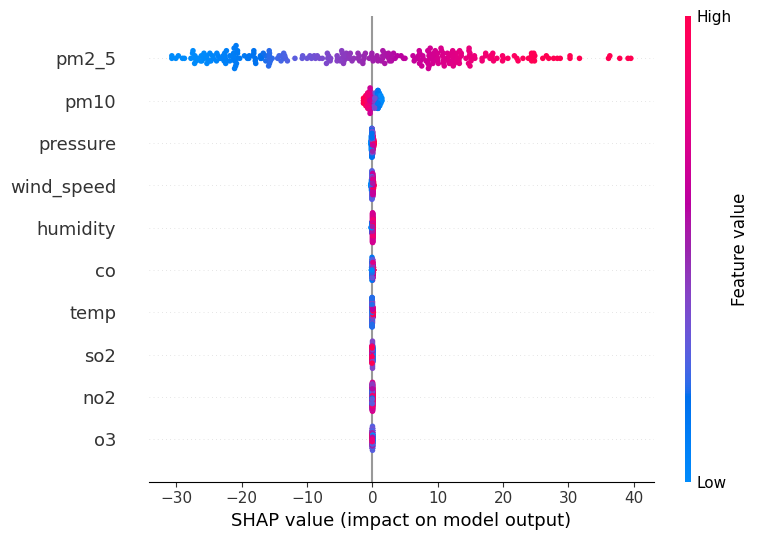

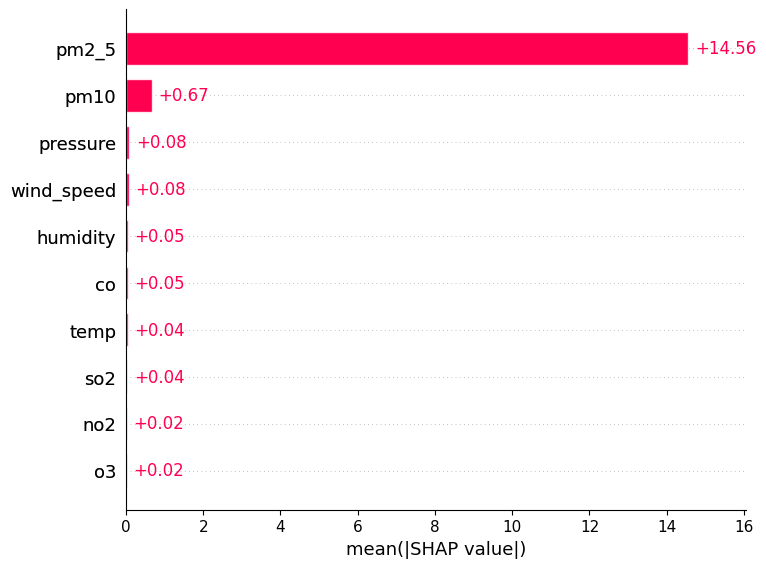

In [37]:
# === SHAP Explainability ===
print("🔍 Generating SHAP explanations...")
explainer = shap.Explainer(model2, X)
shap_values = explainer(X)

# SHAP summary plot
shap.summary_plot(shap_values, X)

# SHAP bar plot
shap.plots.bar(shap_values)

INFERENCE

1. PREDICTION USING RIDGE REGRESSION MODEL



In [38]:
# === Load trained XGBoost model ===
model = joblib.load("model_ridge.pkl")

# === Extract expected feature names from model ===
feature_columns = model.feature_names_in_

# === Load full dataset with features ===
df = pd.read_csv("karachi_aqi.csv")

# === Check for missing features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f"❌ Missing columns in karachi_aqi.csv: {missing_cols}")

# === Get last 72 rows (3 days hourly data) ===
df_last = df.tail(72).copy()

# === Prepare features ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Get datetime column (if exists) ===
if "datetime" in df_last.columns:
    datetime_col = pd.to_datetime(df_last["datetime"])
else:
    datetime_col = pd.date_range(start="2025-06-26", periods=72, freq="H")

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days using XGBoost:")
for dt, pred in zip(datetime_col, y_pred):
    print(f"{dt} → AQI: {round(pred, 2)}")



📈 Predicted AQI for Next 3 Days using XGBoost:
2025-06-26 00:00:00 → AQI: 120.17
2025-06-26 01:00:00 → AQI: 117.38
2025-06-26 02:00:00 → AQI: 112.83
2025-06-26 03:00:00 → AQI: 107.78
2025-06-26 04:00:00 → AQI: 103.36
2025-06-26 05:00:00 → AQI: 99.35
2025-06-26 06:00:00 → AQI: 92.22
2025-06-26 07:00:00 → AQI: 88.92
2025-06-26 08:00:00 → AQI: 88.18
2025-06-26 09:00:00 → AQI: 88.6
2025-06-26 10:00:00 → AQI: 88.96
2025-06-26 11:00:00 → AQI: 89.33
2025-06-26 12:00:00 → AQI: 90.2
2025-06-26 13:00:00 → AQI: 90.48
2025-06-26 14:00:00 → AQI: 90.46
2025-06-26 15:00:00 → AQI: 90.32
2025-06-26 16:00:00 → AQI: 90.28
2025-06-26 17:00:00 → AQI: 90.62
2025-06-26 18:00:00 → AQI: 90.6
2025-06-26 19:00:00 → AQI: 91.24
2025-06-26 20:00:00 → AQI: 90.46
2025-06-26 21:00:00 → AQI: 91.18
2025-06-26 22:00:00 → AQI: 92.41
2025-06-26 23:00:00 → AQI: 93.32
2025-06-27 00:00:00 → AQI: 94.12
2025-06-27 01:00:00 → AQI: 94.11
2025-06-27 02:00:00 → AQI: 92.65
2025-06-27 03:00:00 → AQI: 90.12
2025-06-27 04:00:00 → AQI:

/tmp/ipython-input-121411646.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_col = pd.date_range(start="2025-06-26", periods=72, freq="H")


2. PREDICTION USING XGBOOST MODEL

In [39]:
# === Load trained XGBoost model ===
model = joblib.load("model_xgboost1.pkl")

# === Extract expected feature names from model ===
feature_columns = model.feature_names_in_

# === Load full dataset with features ===
df = pd.read_csv("karachi_aqi.csv")

# === Check for missing features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f"❌ Missing columns in karachi_aqi.csv: {missing_cols}")

# === Get last 72 rows (3 days hourly data) ===
df_last = df.tail(72).copy()

# === Prepare features ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Get datetime column (if exists) ===
if "datetime" in df_last.columns:
    datetime_col = pd.to_datetime(df_last["datetime"])
else:
    datetime_col = pd.date_range(start="2025-06-26", periods=72, freq="H")

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days using XGBoost:")
for dt, pred in zip(datetime_col, y_pred):
    print(f"{dt} → AQI: {round(pred, 2)}")


📈 Predicted AQI for Next 3 Days using XGBoost:
2025-06-26 00:00:00 → AQI: 122.16999816894531
2025-06-26 01:00:00 → AQI: 119.1500015258789
2025-06-26 02:00:00 → AQI: 114.0999984741211
2025-06-26 03:00:00 → AQI: 108.58999633789062
2025-06-26 04:00:00 → AQI: 103.68000030517578
2025-06-26 05:00:00 → AQI: 98.66999816894531
2025-06-26 06:00:00 → AQI: 91.94000244140625
2025-06-26 07:00:00 → AQI: 88.66000366210938
2025-06-26 08:00:00 → AQI: 88.02999877929688
2025-06-26 09:00:00 → AQI: 88.44000244140625
2025-06-26 10:00:00 → AQI: 88.77999877929688
2025-06-26 11:00:00 → AQI: 89.13999938964844
2025-06-26 12:00:00 → AQI: 89.83999633789062
2025-06-26 13:00:00 → AQI: 90.06999969482422
2025-06-26 14:00:00 → AQI: 90.0199966430664
2025-06-26 15:00:00 → AQI: 89.91999816894531
2025-06-26 16:00:00 → AQI: 89.86000061035156
2025-06-26 17:00:00 → AQI: 90.18000030517578
2025-06-26 18:00:00 → AQI: 90.18000030517578
2025-06-26 19:00:00 → AQI: 90.70999908447266
2025-06-26 20:00:00 → AQI: 90.04000091552734
2025-

/tmp/ipython-input-1917801457.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_col = pd.date_range(start="2025-06-26", periods=72, freq="H")


3. PREDICTION USING LINEAR REGRESSION MODEL

In [40]:
# === Load trained XGBoost model ===
model = joblib.load("model_linear1.pkl")

# === Extract expected feature names from model ===
feature_columns = model.feature_names_in_

# === Load full dataset with features ===
df = pd.read_csv("karachi_aqi.csv")

# === Check for missing features ===
missing_cols = set(feature_columns) - set(df.columns)
if missing_cols:
    raise ValueError(f"❌ Missing columns in karachi_aqi.csv: {missing_cols}")

# === Get last 72 rows (3 days hourly data) ===
df_last = df.tail(72).copy()

# === Prepare features ===
X = df_last[feature_columns]

# === Predict AQI ===
y_pred = model.predict(X)

# === Get datetime column (if exists) ===
if "datetime" in df_last.columns:
    datetime_col = pd.to_datetime(df_last["datetime"])
else:
    datetime_col = pd.date_range(start="2025-06-26", periods=72, freq="H")

# === Print Predictions ===
print("\n📈 Predicted AQI for Next 3 Days using XGBoost:")
for dt, pred in zip(datetime_col, y_pred):
    print(f"{dt} → AQI: {round(pred, 2)}")


📈 Predicted AQI for Next 3 Days using XGBoost:
2025-06-26 00:00:00 → AQI: 120.18
2025-06-26 01:00:00 → AQI: 117.39
2025-06-26 02:00:00 → AQI: 112.84
2025-06-26 03:00:00 → AQI: 107.79
2025-06-26 04:00:00 → AQI: 103.36
2025-06-26 05:00:00 → AQI: 99.35
2025-06-26 06:00:00 → AQI: 92.22
2025-06-26 07:00:00 → AQI: 88.91
2025-06-26 08:00:00 → AQI: 88.18
2025-06-26 09:00:00 → AQI: 88.59
2025-06-26 10:00:00 → AQI: 88.94
2025-06-26 11:00:00 → AQI: 89.3
2025-06-26 12:00:00 → AQI: 90.19
2025-06-26 13:00:00 → AQI: 90.46
2025-06-26 14:00:00 → AQI: 90.45
2025-06-26 15:00:00 → AQI: 90.32
2025-06-26 16:00:00 → AQI: 90.3
2025-06-26 17:00:00 → AQI: 90.65
2025-06-26 18:00:00 → AQI: 90.62
2025-06-26 19:00:00 → AQI: 91.26
2025-06-26 20:00:00 → AQI: 90.47
2025-06-26 21:00:00 → AQI: 91.18
2025-06-26 22:00:00 → AQI: 92.42
2025-06-26 23:00:00 → AQI: 93.32
2025-06-27 00:00:00 → AQI: 94.11
2025-06-27 01:00:00 → AQI: 94.11
2025-06-27 02:00:00 → AQI: 92.65
2025-06-27 03:00:00 → AQI: 90.12
2025-06-27 04:00:00 → AQI

/tmp/ipython-input-3315903594.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  datetime_col = pd.date_range(start="2025-06-26", periods=72, freq="H")


DEPLOYMENT USING GRADIO



PREDICTION OF AQI FOR THE NEXT 3 DAYS USING COLORS TO REPRESENT AQI LEVELS AND HOURLY AQI DATA GRAPH

In [41]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import datetime
from tensorflow.keras.models import load_model
from zoneinfo import ZoneInfo

# === AQI Alert Level Function ===
def get_alert_level(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# === Color Mapping for AQI Levels ===
def get_alert_color(level):
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")

# === Main Prediction Function ===
def predict_aqi(current_date_str, model_name):
    try:
        current_date = datetime.datetime.strptime(current_date_str, "%Y-%m-%d %H:%M:%S")
        # df = pd.read_csv("karachi_aqi.csv").dropna()
        predictions = []

        if model_name == "XGBoost":
            model = joblib.load("model_xgboost1.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "LinearRegression":
            model = joblib.load("model_linear1.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)

        elif model_name == "Ridge Regression":
            model = joblib.load("model_ridge.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)




        # === Calculate Predictions ===
        timestamps = [current_date + datetime.timedelta(hours=i) for i in range(72)]
        predictions = np.array(predictions)
        daily_avgs = [np.mean(predictions[i*24:(i+1)*24]) for i in range(3)]
        aqi_values = [str(round(val)) for val in daily_avgs]

        alerts_html = []
        for avg in daily_avgs:
            level = get_alert_level(avg)
            color = get_alert_color(level)
            alerts_html.append(
                f"<div style='background-color:{color};padding:8px;font-weight:bold;text-align:center'>{level}</div>"
            )

        # === Current AQI from latest data ===
        current_aqi = round(df["aqi_index"].iloc[-1])
        current_alert_level = get_alert_level(current_aqi)
        current_color = get_alert_color(current_alert_level)
        current_alert_html = f"<div style='background-color:{current_color};padding:8px;font-weight:bold;text-align:center'>{current_alert_level}</div>"

        # === Plot Hourly Line Chart ===
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(timestamps, predictions, color='skyblue', linewidth=2)
        ax.set_title(f"Hourly AQI Forecast - Model: {model_name}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Predicted AQI")
        ax.grid(True)
        fig.autofmt_xdate()

        return (
            str(current_aqi), current_alert_html,
            aqi_values[0], alerts_html[0],
            aqi_values[1], alerts_html[1],
            aqi_values[2], alerts_html[2],
            fig
        )

    except Exception as e:
        return str(e), "", "", "", "", "", "", "", None

# === Gradio UI ===
with gr.Blocks(title="Karachi AQI Forecast ☁️", css="""
#predict-btn {
    background-color: skyblue !important;
    color: black !important;
    font-weight: bold;
    border-radius: 6px;
    padding: 10px 20px;
    border: 1px solid #0077cc;
}
""") as demo:

    gr.Markdown("## ☁️ Karachi Air Quality Forecast - Hourly AQI Prediction")

    now_local = datetime.datetime.now(ZoneInfo("Asia/Karachi")).replace(microsecond=0)
    default_date = now_local.strftime("%Y-%m-%d %H:%M:%S")

    with gr.Row():
        current_date_display = gr.Textbox(label="Current Date And Time (Asia/Karachi)", value=default_date, interactive=False)
        model_dropdown = gr.Dropdown(
            ["XGBoost", "Ridge Regression", "LinearRegression"],
            label="Select Model"
        )

    predict_button = gr.Button("☁️ Predict AQI", elem_id="predict-btn")

    gr.Markdown("### 📍 Current AQI & Alert Level")
    with gr.Row():
        current_aqi_val = gr.Textbox(label="Current AQI")
        current_alert = gr.HTML()

    gr.Markdown("### 📅 Forecast: Next 3 Days")
    with gr.Row():
        d1_val = gr.Textbox(label="Day 1 AQI")
        d1_alert = gr.HTML()
    with gr.Row():
        d2_val = gr.Textbox(label="Day 2 AQI")
        d2_alert = gr.HTML()
    with gr.Row():
        d3_val = gr.Textbox(label="Day 3 AQI")
        d3_alert = gr.HTML()

    aqi_plot = gr.Plot(label="Hourly AQI Forecast (Next 72 Hours)")

    predict_button.click(
        predict_aqi,
        inputs=[current_date_display, model_dropdown],
        outputs=[
            current_aqi_val, current_alert,
            d1_val, d1_alert,
            d2_val, d2_alert,
            d3_val, d3_alert,
            aqi_plot
        ]
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d57f74e8da74d88af9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [4]:
from fastapi import FastAPI
from pydantic import BaseModel
from typing import List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import datetime
import io
import base64
from fastapi.responses import JSONResponse
import os

app = FastAPI(title="Karachi AQI Forecast API")

# === Helper Functions ===

def get_alert_level(aqi: float) -> str:
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

def get_alert_color(level: str) -> str:
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")


# === Pydantic Request Schema ===

class AQIRequest(BaseModel):
    current_date: str  # format: "YYYY-MM-DD HH:MM:SS"
    model_name: str    # "XGBoost", "LinearRegression", "Ridge Regression"

# === Main Endpoint ===

@app.post("/predict_aqi")
def predict_aqi(request: AQIRequest):
    try:
        # Parse date
        current_date = datetime.datetime.strptime(request.current_date, "%Y-%m-%d %H:%M:%S")

        # Load CSV
        df_path = "karachi_aqi.csv"
        if not os.path.exists(df_path):
            return JSONResponse(status_code=404, content={"error": "karachi_aqi.csv not found."})

        df = pd.read_csv(df_path).dropna()

        # Load model
        model_name = request.model_name
        model_path = {
            "XGBoost": "model_xgboost1.pkl",
            "LinearRegression": "model_linear1.pkl",
            "Ridge Regression": "model_ridge.pkl"
        }.get(model_name)

        if not model_path or not os.path.exists(model_path):
            return JSONResponse(status_code=400, content={"error": "Model not found or invalid model name."})

        model = joblib.load(model_path)

        # Get last 72 records and prepare features
        X = df.tail(72)[model.feature_names_in_]
        predictions = model.predict(X)

        # Compute daily averages
        timestamps = [current_date + datetime.timedelta(hours=i) for i in range(72)]
        daily_avgs = [np.mean(predictions[i*24:(i+1)*24]) for i in range(3)]
        aqi_values = [round(val) for val in daily_avgs]

        alert_levels = [get_alert_level(val) for val in aqi_values]
        alert_colors = [get_alert_color(level) for level in alert_levels]

        # Current AQI
        current_aqi = round(df["aqi_index"].iloc[-1])
        current_alert_level = get_alert_level(current_aqi)
        current_alert_color = get_alert_color(current_alert_level)

        # Plot AQI
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(timestamps, predictions, color='skyblue', linewidth=2)
        ax.set_title(f"Hourly AQI Forecast - Model: {model_name}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Predicted AQI")
        ax.grid(True)
        fig.autofmt_xdate()

        # Convert plot to base64 image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        image_base64 = base64.b64encode(buf.read()).decode("utf-8")

        return {
            "current_aqi": current_aqi,
            "current_alert_level": current_alert_level,
            "current_alert_color": current_alert_color,
            "daily_aqi_values": aqi_values,
            "daily_alert_levels": alert_levels,
            "daily_alert_colors": alert_colors,
            "aqi_plot_base64": image_base64
        }

    except Exception as e:
        return JSONResponse(status_code=500, content={"error": str(e)})


**☁️ Karachi Air Quality Forecast | Real Time Daily AQI Forecast Model - Next 3 Days**

In [3]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap
import joblib
import datetime
import requests
from tensorflow.keras.models import load_model
from zoneinfo import ZoneInfo

AIR_API_KEY = "a1c4ea3c-c116-43fb-9d98-81004cf3f771"

def get_live_aqi():
    try:
        url = f"http://api.airvisual.com/v2/city?city=Karachi&state=Sindh&country=Pakistan&key={AIR_API_KEY}"
        response = requests.get(url)
        data = response.json()
        return data["data"]["current"]["pollution"]["aqius"]
    except:
        return None

def get_alert_level(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

def get_alert_color(level):
    return {
        "Good": "#00e400",
        "Moderate": "#ffff00",
        "Unhealthy for Sensitive Groups": "#ff7e00",
        "Unhealthy": "#ff0000",
        "Very Unhealthy": "#8f3f97",
        "Hazardous": "#7e0023"
    }.get(level, "#ffffff")

def predict_aqi(current_date_str, model_name):
    try:
        df = pd.read_csv("karachi_aqi.csv").dropna()
        predictions = []

        if model_name == "XGBoost":
            model = joblib.load("model_xgboost1.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)
            current_pred = model.predict([X.iloc[-1]])[0]

        elif model_name == "Ridge Regression":
            model = joblib.load("model_ridge.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)
            current_pred = model.predict([X.iloc[-1]])[0]

        elif model_name == "LinearRegression":
            model = joblib.load("model_linear1.pkl")
            X = df.tail(72)[model.feature_names_in_]
            predictions = model.predict(X)
            current_pred = model.predict([X.iloc[-1]])[0]




        current_aqi = round(current_pred)
        daily_avgs = [np.mean(predictions[i * 24:(i + 1) * 24]) for i in range(3)]

        live_aqi = get_live_aqi()
        correction_factor = 0
        if live_aqi is not None:
            correction_factor = live_aqi - current_aqi
            current_aqi += correction_factor
            daily_avgs = [val + correction_factor for val in daily_avgs]

        aqi_values = [str(round(val)) for val in daily_avgs]

        alerts_html = []
        for avg in daily_avgs:
            level = get_alert_level(avg)
            color = get_alert_color(level)
            alerts_html.append(
                f"<div style='background-color:{color};color:black;padding:8px;font-weight:bold;text-align:center'>{level}</div>"
            )

        current_alert_level = get_alert_level(current_aqi)
        current_html = f"<div style='background-color:{get_alert_color(current_alert_level)};color:black;padding:8px;font-weight:bold;text-align:center'>{current_alert_level}</div>"

        if live_aqi is not None:
            live_level = get_alert_level(live_aqi)
            live_html = f"<div style='background-color:{get_alert_color(live_level)};color:black;padding:8px;font-weight:bold;text-align:center'>{live_level}</div>"
            error_info = f"<div style='text-align:center;font-size:13px;color:#444'>Live vs Model AQI Error: ±{abs(live_aqi - current_aqi):.2f}</div>"
        else:
            live_html = "<div style='padding:8px;text-align:center'>Live AQI unavailable</div>"
            error_info = ""

        advisory = {
            "Good": "Air quality is satisfactory. Enjoy your day!",
            "Moderate": "Air quality is acceptable. Sensitive individuals should limit outdoor exertion.",
            "Unhealthy for Sensitive Groups": "Sensitive groups may experience health effects.",
            "Unhealthy": "Everyone may begin to experience health effects. Limit outdoor exertion.",
            "Very Unhealthy": "Health alert: serious effects possible. Avoid outdoor activities.",
            "Hazardous": "Emergency conditions. Stay indoors and limit exposure!"
        }.get(current_alert_level, "No advisory available.")

        advisory_html = f"<div style='background-color:{get_alert_color(current_alert_level)};color:black;padding:12px;font-weight:bold;text-align:center;font-size:15px'>{advisory}</div>{error_info}"

        fig = plt.figure(figsize=(11.5, 5))
        spec = gridspec.GridSpec(ncols=2, nrows=1, width_ratios=[1.8, 4])
        ax_scale = fig.add_subplot(spec[0])
        ax = fig.add_subplot(spec[1])

        for low, high, label, color in [
            (0, 50, "Good", "#00e400"),
            (51, 100, "Moderate", "#ffff00"),
            (101, 150, "Unhealthy for Sensitive Groups", "#ff7e00"),
            (151, 200, "Unhealthy", "#ff0000"),
            (201, 300, "Very Unhealthy", "#8f3f97"),
            (301, 550, "Hazardous", "#7e0023")
        ]:
            ax_scale.barh((low + high) / 2, 1, high - low, color=color, edgecolor="black")
            ax_scale.text(0.5, (low + high) / 2, "\n".join(textwrap.wrap(label, 20)), va="center", ha="center", fontsize=8.8, weight="bold")

        ax_scale.set_ylim(0, 550)
        ax_scale.set_xlim(0, 1)
        ax_scale.set_yticks([0, 50, 100, 150, 200, 300, 500])
        ax_scale.set_yticklabels(["0", "50", "100", "150", "200", "300", "500"])
        ax_scale.tick_params(axis='x', bottom=False, labelbottom=False)
        ax_scale.set_title("AQI Scale", fontsize=10)

        bars = ["Current", "Day 1", "Day 2", "Day 3"]
        bar_vals = [current_aqi] + [float(v) for v in aqi_values]
        bar_colors = [get_alert_color(get_alert_level(v)) for v in bar_vals]

        ax.bar(bars, bar_vals, color=bar_colors, edgecolor="black")
        ax.set_title("Current + 3-Day AQI Forecast")
        ax.set_ylabel("AQI Level")
        ax.set_ylim(0, max(bar_vals + [500]) + 50)
        ax.grid(True, axis='y')

        return (
            str(round(current_aqi)), current_html,
            str(live_aqi) if live_aqi else "Unavailable", live_html,
            aqi_values[0], alerts_html[0],
            aqi_values[1], alerts_html[1],
            aqi_values[2], alerts_html[2],
            fig, advisory_html
        )

    except Exception as e:
        return str(e), "", "", "", "", "", "", "", None, ""

# === Gradio Interface ===
with gr.Blocks(title="Karachi AQI Forecast", css="#predict-btn {background-color: skyblue !important; color: black !important; font-weight: bold; border-radius: 6px; padding: 10px 20px; border: 1px solid #0077cc;}") as demo:
    gr.Markdown("## ☁️ Karachi Air Quality Forecast  |  Real Time Daily AQI Forecast Model - Next 3 Days")

    now_local = datetime.datetime.now(ZoneInfo("Asia/Karachi")).replace(microsecond=0)
    default_date = now_local.strftime("%Y-%m-%d %H:%M:%S")

    with gr.Row():
        current_date_display = gr.Textbox(label="Current Date And Time (Asia/Karachi)", value=default_date, interactive=False)
        model_dropdown = gr.Dropdown([ "XGBoost", "Ridge Regression", "LinearRegression"], label="Select Model")

    predict_button = gr.Button("☁️ Predict AQI", elem_id="predict-btn")

    gr.Markdown("### 📍 Current AQI Values")
    with gr.Row():
        current_aqi_val = gr.Textbox(label="Model AQI", interactive=False)
        current_aqi_level = gr.HTML()
    with gr.Row():
        live_aqi_val = gr.Textbox(label="Live AQI ", interactive=False)
        live_aqi_level = gr.HTML()

    gr.Markdown("### 🕕 Forecast: Next 3 Days")
    with gr.Row():
        d1_val = gr.Textbox(label="Day 1 AQI")
        d1_alert = gr.HTML()
    with gr.Row():
        d2_val = gr.Textbox(label="Day 2 AQI")
        d2_alert = gr.HTML()
    with gr.Row():
        d3_val = gr.Textbox(label="Day 3 AQI")
        d3_alert = gr.HTML()

    aqi_plot = gr.Plot(label="AQI Forecast Plot")
    gr.Markdown("### ⚠️ AQI Health Advisory")
    advisory_box = gr.HTML()

    predict_button.click(
        predict_aqi,
        inputs=[current_date_display, model_dropdown],
        outputs=[
            current_aqi_val, current_aqi_level,
            live_aqi_val, live_aqi_level,
            d1_val, d1_alert,
            d2_val, d2_alert,
            d3_val, d3_alert,
            aqi_plot, advisory_box
        ]
    )

    demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://49fa10697ff23a02d2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
